In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [45]:
df=pd.read_csv("linear_data.csv")

In [46]:
df.head()

,x,y
0,0.00000,4.447692
1,0.02004,5.024612
2,0.04008,5.869593
3,0.06012,4.722490
4,0.08016,4.877101


<Axes: xlabel='x', ylabel='y'>

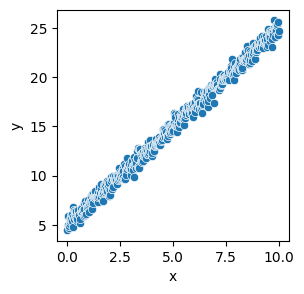

In [47]:
plt.figure(figsize=(3,3))
sns.scatterplot(x=df["x"], y=df["y"])


In [48]:
lr=LinearRegression()

In [49]:
df1=pd.read_csv("nonlinear_data.csv")

In [50]:
df1.head()

,x,y
0,0.00000,-0.155043
1,0.02004,0.081809
2,0.04008,-0.014298
3,0.06012,0.143978
4,0.08016,0.019553


<Axes: xlabel='x', ylabel='y'>

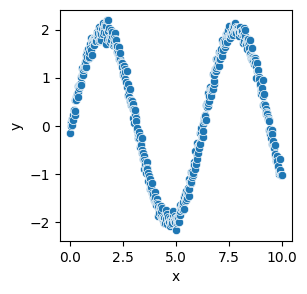

In [51]:
plt.figure(figsize=(3,3))
sns.scatterplot(x=df1["x"], y=df1["y"])


In [52]:
df.corr()

,x,y
x,1.00000,0.99644
y,0.99644,1.00000


In [53]:
df1.corr()

,x,y
x,1.000000,-0.065736
y,-0.065736,1.000000


In [ ]:
linear_x=df[["x"]]
linear_y=df[["y"]]


In [55]:
model_linear=lr.fit(linear_x, linear_y)
model_linear.score(linear_x, linear_y)

0.9928923730526016

In [57]:
#prediction

In [58]:
pred1=model_linear.predict(linear_x)

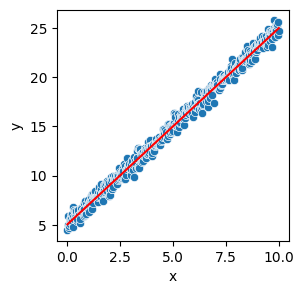

In [60]:
plt.figure(figsize=(3,3))
sns.scatterplot(x=df["x"], y=df["y"])
plt.plot(linear_x, pred1, color="r" )

In [61]:
nonlinear_x=df1[["x"]]
nonlinear_y=df1[["y"]]


In [62]:
model_nonlinear=lr.fit(nonlinear_x, nonlinear_y)
model_nonlinear.score(nonlinear_x, nonlinear_y)

0.004321199719043656

In [63]:
pred2=model_nonlinear.predict(nonlinear_x)

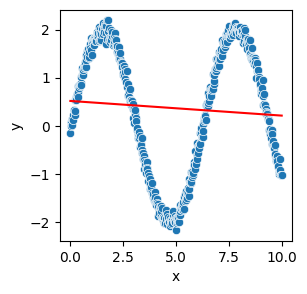

In [64]:
plt.figure(figsize=(3,3))
sns.scatterplot(x=df1["x"], y=df1["y"])
plt.plot(nonlinear_x, pred2, color="r" )

In [74]:
poly= PolynomialFeatures(degree=9)

In [75]:
model_poly=poly.fit_transform(nonlinear_x, nonlinear_y)
model_poly

array([[1.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.00000000e+00, 2.00400802e-02, 4.01604813e-04, ...,
        1.29806422e-12, 2.60133111e-14, 5.21308840e-16],
       [1.00000000e+00, 4.00801603e-02, 1.60641925e-03, ...,
        1.66152221e-10, 6.65940764e-12, 2.66910126e-13],
       ...,
       [1.00000000e+00, 9.95991984e+00, 9.92000032e+01, ...,
        9.72278991e+06, 9.68382082e+07, 9.64500791e+08],
       [1.00000000e+00, 9.97995992e+00, 9.95996000e+01, ...,
        9.86056000e+06, 9.84079936e+07, 9.82107832e+08],
       [1.00000000e+00, 1.00000000e+01, 1.00000000e+02, ...,
        1.00000000e+07, 1.00000000e+08, 1.00000000e+09]], shape=(500, 10))

In [76]:
data=pd.DataFrame(model_poly)

In [77]:
data

,0,1,2,3,4,5,6,7,8,9
0,1.0,0.00000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,1.0,0.02004,0.000402,0.000008,1.612864e-07,3.232193e-09,6.477340e-11,1.298064e-12,2.601331e-14,5.213088e-16
2,1.0,0.04008,0.001606,0.000064,2.580583e-06,1.034302e-07,4.145498e-09,1.661522e-10,6.659408e-12,2.669101e-13
3,1.0,0.06012,0.003614,0.000217,1.306420e-05,7.854229e-07,4.721981e-08,2.838866e-09,1.706733e-10,1.026092e-11
4,1.0,0.08016,0.006426,0.000515,4.128932e-05,3.309766e-06,2.653119e-07,2.126748e-08,1.704808e-09,1.366580e-10
...,...,...,...,...,...,...,...,...,...,...
495,1.0,9.91984,98.403219,976.144159,9.683194e+03,9.605573e+04,9.528574e+05,9.452193e+06,9.376424e+07,9.301262e+08
496,1.0,9.93988,98.801210,982.072144,9.761679e+03,9.702992e+04,9.644657e+05,9.586673e+06,9.529038e+07,9.471749e+08
497,1.0,9.95992,99.200003,988.024080,9.840641e+03,9.801199e+04,9.761916e+05,9.722790e+06,9.683821e+07,9.645008e+08
498,1.0,9.97996,99.599600,994.000016,9.920080e+03,9.900200e+04,9.880360e+05,9.860560e+06,9.840799e+07,9.821078e+08


In [81]:
model3=lr.fit(data, nonlinear_y)

In [82]:
model3.score(data, nonlinear_y)

0.9950452753249605

In [83]:
import pickle
pickle.dump(model_linear, open("model.pkl", "wb"))